# 02 — Temporal validation, tuning, and the bootstrap

Notebook 01 showed the basic `spec → solve → predict → performance`
loop. This one walks through the *honest assessment* side of the
package:

* `mc.time_split` and `mc.expanding_window` for walk-forward CV.
* `mc.tune` for picking a hyperparameter while keeping CV-for-tuning
  and CV-for-assessment separate (ESL §7.10.2).
* `mc.bootstrap` for coefficient CIs when the closed-form SE isn't
  defined (lasso, ridge, logistic; ESL §7.11).
* `mc.performance_over_time` for the deployment-monitoring view.

The UCI German Credit data has no time column. We attach a *synthetic*
`origination_dt` so the temporal API has something to chew on; the
labels are exchangeable across the date axis, so the temporal patterns
you'll see are just splitter mechanics, not real drift.

## 1. Load with a synthetic origination date

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import model_crafter as mc
from model_crafter.assumptions import MinimumBinSize
from model_crafter.terms.woe import fit_binnings
import _german

df = _german.add_synthetic_origination(
    _german.load_german(),
    start="2018-01-01",
    end="2022-12-31",
    seed=0,
)
print(f"n = {len(df):,}")
print(f"date range: {df['origination_dt'].min():%Y-%m-%d} → "
      f"{df['origination_dt'].max():%Y-%m-%d}")
df[["origination_dt", "default"]].head()

n = 1,000
date range: 2018-01-01 → 2022-12-28


,origination_dt,default
0,2018-01-01,0
1,2018-01-06,1
2,2018-01-07,0
3,2018-01-09,0
4,2018-01-10,1


## 2. Time split

`mc.time_split` sorts by the time column and slices into contiguous,
non-overlapping pieces. We hold out the most recent 25 % for honest
test scoring, leaving 75 % for the tune-then-refit pipeline.

In [2]:
train, test = mc.time_split(
    df, time_col="origination_dt", ratios=(0.75, 0.25),
)
print(f"train: {len(train):,}    {train['origination_dt'].min():%Y-%m-%d} → "
      f"{train['origination_dt'].max():%Y-%m-%d}")
print(f"test:  {len(test):,}    {test['origination_dt'].min():%Y-%m-%d} → "
      f"{test['origination_dt'].max():%Y-%m-%d}")

train: 750    2018-01-01 → 2021-10-26
test:  250    2021-10-27 → 2022-12-28


## 3. Build the spec and fit binnings on train

The spec is the same WoE-encoded logistic as notebook 01. We fit
bins on the *training* slice only — the held-out test never sees the
bin learner.

Note on bin leakage across CV folds: in this demo we fit bins once on
the whole training slice and reuse those bins across all CV folds.
That's *technically* leaky (the bins know about every training row,
including ones held out as the validation in any given fold). The
cleanly per-fold pattern would re-fit bins inside each fold; the
package's `cross_validate` does not yet expose that hook, so for v0
this is the pragmatic compromise.

In [3]:
features = (
    mc.woe("duration_months",        bins=mc.monotonic(min_bin_size=0.07))
    + mc.woe("credit_amount",        bins=mc.monotonic(min_bin_size=0.07))
    + mc.woe("age_years",            bins=mc.monotonic(min_bin_size=0.07))
    + mc.woe("installment_rate_pct", bins=mc.monotonic(min_bin_size=0.07))
    + mc.woe("checking_status",      bins=mc.categorical(group_rare=0.0))
    + mc.woe("credit_history",       bins=mc.categorical(group_rare=0.10))
    + mc.woe("savings",              bins=mc.categorical(group_rare=0.12))
    + mc.woe("employment_since",     bins=mc.categorical(group_rare=0.07))
    + mc.woe("housing",              bins=mc.categorical(group_rare=0.0))
    + mc.woe("purpose",              bins=mc.categorical(group_rare=0.08))
)
spec_template = mc.linear(
    target = "default",
    features = features,
    loss    = mc.logistic,
    penalty = mc.l2(0.1),  # placeholder, will be tuned
)
spec_fitted = fit_binnings(spec_template, train)
print(spec_fitted)

LinearSpec(target='default', features=(WoETerm(column='duration_months', binning=MonotonicBinning(min_bin_size=0.07, max_bins=20, kind='monotonic'), fitted=BinningResult(column='duration_months', kind='numeric', edges=(9.0, 12.0, 18.0, 24.0, 36.0), categories=(), bin_labels=('(-inf, 9]', '(9, 12]', '(12, 18]', '(18, 24]', '(24, 36]', '(36, +inf]'), has_missing_bin=False, n_events=(19, 44, 37, 48, 43, 32), n_nonevents=(96, 126, 100, 112, 59, 34), woe=(-0.7467865355013575, -0.19241111172149877, -0.13347478724888365, 0.010952583572844293, 0.5391266328169358, 0.7926227725722593), iv=0.18839621196298267), assumptions=(AtLeastOneEventPerBin(name='AtLeastOneEventPerBin', severity=<Severity.HARD: 'hard'>, requires_solution=False, requires_cv=False), MinimumBinSize(min_fraction=0.05, name='MinimumBinSize', severity=<Severity.HARD: 'hard'>, requires_solution=False, requires_cv=False), MonotonicEventRate(name='MonotonicEventRate', severity=<Severity.HARD: 'hard'>, requires_solution=False, require

## 4. Tune the L2 penalty with walk-forward CV

`mc.expanding_window(...)` produces an expanding-window splitter: at
each fold the training window grows; the validation window slides
forward by `horizon`. The `gap=` argument is for label-maturation
buffers — important for real credit data where today's loan doesn't
have a 12-month default flag until 12 months from now. Here we set
gap to a token 30 days since the labels are synthetic.

`mc.tune` walks a grid, runs CV for each, and picks the best by
`metric`. We use `mc.log_grid` for log-spaced lambdas and the default
`best_mean` selection rule. (`mc.one_se_rule` is also available — it
picks the simplest model within 1 SD of the best, ESL §7.10. On a
flat curve like this one it tends toward the strongest shrinkage,
which is intentional but not always what you want.)

In [4]:
import dataclasses

def make_spec(lam: float) -> mc.linear.__annotations__.get("return", object):
    # Frozen dataclass: replace() returns a new spec with a different penalty.
    return dataclasses.replace(spec_fitted, penalty=mc.l2(lam))

splitter = mc.expanding_window(
    time_col  = "origination_dt",
    n_folds   = 4,
    horizon   = "180D",
    gap       = "30D",
    min_train = "365D",
)

grid = list(mc.log_grid(1e-4, 1.0, n=15))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    tuned = mc.tune(
        spec_fn  = make_spec,
        grid     = grid,
        data     = train,
        splitter = splitter,
        metric   = mc.auc,
        # rule defaults to best_mean (argmax of metric_mean)
    )

print(f"chosen lambda: {tuned.best_param:.4g}")
print(f"selection rule: best_mean (default)")
tuned.cv_curve.round(4)

chosen lambda: 0.005179
selection rule: best_mean (default)


,metric_mean,metric_sd
param,,
1.000000,0.7988,0.0616
0.517947,0.7988,0.0610
0.268270,0.8003,0.0592
0.138950,0.8013,0.0582
0.071969,0.8039,0.0579
0.037276,0.8074,0.0576
0.019307,0.8075,0.0570
0.010000,0.8093,0.0542
0.005179,0.8097,0.0520


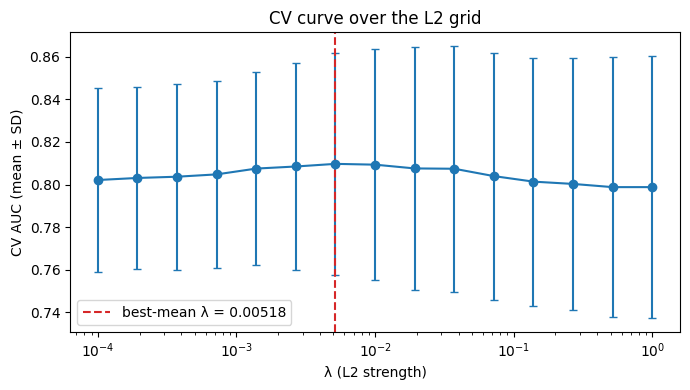

In [5]:
# Plot the CV curve.
fig, ax = plt.subplots(figsize=(7, 4))
curve = tuned.cv_curve.reset_index()
ax.errorbar(curve["param"], curve["metric_mean"], yerr=curve["metric_sd"],
            fmt="o-", capsize=3)
ax.axvline(tuned.best_param, color="C3", linestyle="--",
           label=f"best-mean λ = {tuned.best_param:.3g}")
ax.set_xscale("log")
ax.set_xlabel("λ (L2 strength)")
ax.set_ylabel("CV AUC (mean ± SD)")
ax.set_title("CV curve over the L2 grid")
ax.legend()
plt.tight_layout()
plt.show()

`tuned.solution` is the spec refit on the *full* training
slice at the chosen λ. We use it for the rest of the notebook.

In [6]:
sol = tuned.solution
print(f"converged: {sol.converged}    λ = {sol.spec.penalty.lam:.4g}")
print(f"n_obs (train): {sol.n_obs:,}")

converged: True    λ = 0.005179
n_obs (train): 750


## 5. Bootstrap coefficient CIs

For logistic regression with an L2 penalty there is no closed-form
standard error (the shrinkage is a function of the same data; ESL
§3.4 / DESIGN.md §3.2.3). `mc.bootstrap` resamples with replacement
and refits, giving an empirical distribution of every coefficient.
`coefficient_ci(level=0.95)` returns percentile intervals; the
`base.coefficient_se` field is `None` by design.

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    bs = mc.bootstrap(
        sol,
        data        = train,
        n_boot      = 100,
        stratify    = "default",
        method      = "pairs",
        random_state = 0,
    )

ci = bs.coefficient_ci(level=0.95)
print(f"successful refits: {bs.n_boot}")
ci.round(4).head(10)

successful refits: 100


,lower,upper
(Intercept),-0.9478,-0.7571
duration_months,0.3680,1.0889
credit_amount,0.1317,0.9554
age_years,0.2144,0.9214
installment_rate_pct,0.4516,1.3550
checking_status,0.6223,1.0322
credit_history,0.2937,0.9611
savings,0.1897,1.1132
employment_since,0.2136,0.9754
housing,0.0314,0.8856


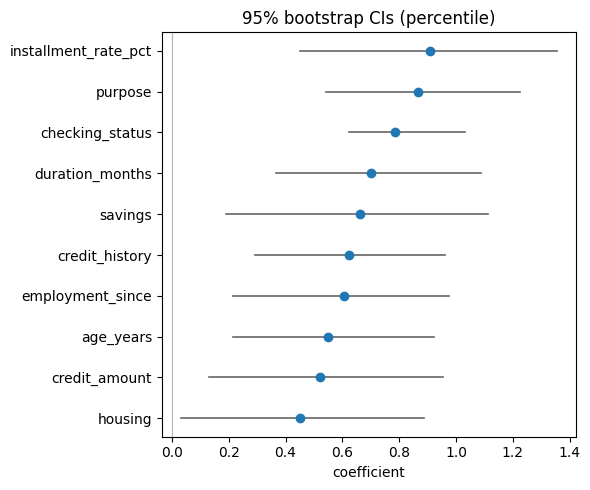

In [8]:
# Visualise the CIs sorted by point estimate magnitude.
point = sol.coefficients.drop("(Intercept)")
ci_no_int = ci.drop("(Intercept)")
order = point.abs().sort_values(ascending=True).index
yvals = np.arange(len(order))

fig, ax = plt.subplots(figsize=(6, 5))
for y, name in zip(yvals, order):
    lo, hi = ci_no_int.loc[name, "lower"], ci_no_int.loc[name, "upper"]
    pt = point[name]
    ax.plot([lo, hi], [y, y], color="0.4", lw=1.2)
    ax.plot([pt], [y], "o", color="C0")
ax.axvline(0, color="0.7", lw=0.8)
ax.set_yticks(yvals); ax.set_yticklabels(order)
ax.set_xlabel("coefficient")
ax.set_title("95% bootstrap CIs (percentile)")
plt.tight_layout()
plt.show()

In a properly-binned WoE model these coefficients want to
sit at ~+1; visibly negative ones are what the post-fit
`WoEMonotonicityPreserved` SOFT check warns on.

## 6. Performance over time

`mc.performance_over_time` runs `mc.performance` on each window of a
splitter and returns a time-indexed bundle. It's the
deployment-monitoring view from DESIGN.md §3.3 — does discrimination
or calibration drift as the population shifts? Here the date axis is
synthetic, so any drift is purely sampling noise, but the API is the
same as on real data.

In [9]:
monitor = mc.rolling_window(
    time_col   = "origination_dt",
    train_size = "180D",     # ignored by performance_over_time, but required
    horizon    = "180D",
    step       = "180D",
    gap        = "0D",
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    perf_t = mc.performance_over_time(
        sol,
        data      = test,
        splitter  = monitor,
        reference = train,
    )

perf_t.summary.round(4)

,n_obs,n_events,auc,ks,brier,log_loss,mean_p,psi
origination_dt,,,,,,,,
2022-07-24,96,28,0.8046,0.5420,0.1558,0.4732,0.2914,0.0950
2022-11-25,48,13,0.7451,0.5231,0.1656,0.5034,0.3078,0.1488


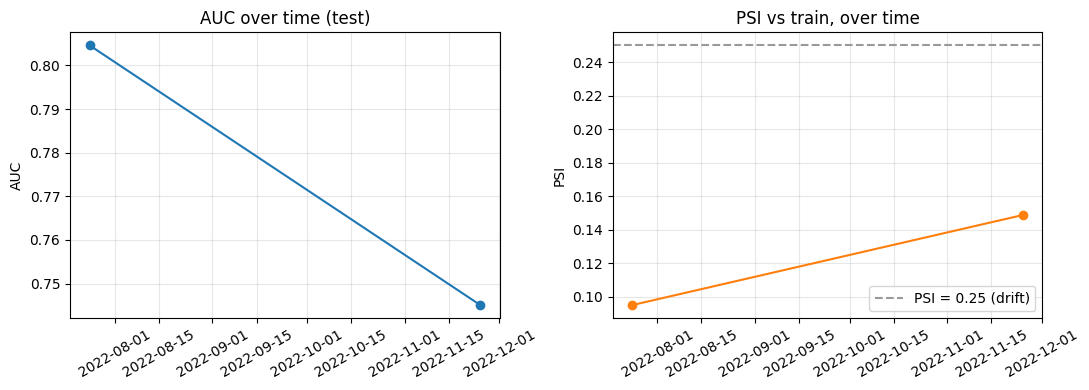

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
s = perf_t.summary.copy()
s.index = pd.to_datetime(s.index)
axes[0].plot(s.index, s["auc"], "o-")
axes[0].set_title("AUC over time (test)")
axes[0].set_ylabel("AUC")
axes[0].grid(True, alpha=0.3)

axes[1].plot(s.index, s["psi"], "o-", color="C1")
axes[1].axhline(0.25, color="0.6", linestyle="--", label="PSI = 0.25 (drift)")
axes[1].set_title("PSI vs train, over time")
axes[1].set_ylabel("PSI")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 7. Final held-out performance

The honest assessment number is `mc.performance(sol, test, ...)` on
the time-held-out slice — the data the tuner never saw.

In [11]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    perf = mc.performance(sol, data=test, reference=train)
print(perf)

PerformanceReport
n=250  events=77 (30.8%)

Discrimination
  AUC                0.8055   (95% CI: 0.7485 – 0.8625, DeLong)
  Gini               0.6110
  KS                 0.5234   (at score 0.2778)
  Cohen's d          1.2355

Calibration
  Brier              0.1612
  ECE  (10 bins)     0.0473
  Log-loss           0.4871
  Slope / Intercept  1.129 / +0.174  (logit regression of y on linear pred)

Stability
  PSI vs reference   0.033   (low; reference: DataFrame)

Distribution
  Mean / Median p̂   0.2936 / 0.2369
  Score range        [0.0220, 0.7913]


## Takeaways

* `mc.time_split` + `mc.expanding_window` give walk-forward CV with
  an explicit label-maturation `gap=`.
* `mc.tune(spec_fn, grid, ..., metric, rule=mc.one_se_rule)` picks
  one λ and refits on the full training slice. The refit is on
  `tuned.solution`.
* `mc.bootstrap(sol, data, n_boot=, stratify=)` is the v0 path for
  honest coefficient CIs — closed-form penalised SEs aren't defined
  (ESL §3.4 / §7.11).
* `mc.performance_over_time(sol, data, splitter, reference=)` is the
  deployment-monitoring view; PSI > 0.25 is the conventional drift
  threshold the report flags.
* CV-for-tuning and CV-for-assessment are separated by design:
  `tune` does tuning, `nested_cv` (not shown here) gives optimism-
  corrected assessment per ESL §7.10.2.